In [13]:
import numpy as np
import pandas as pd
import sklearn as sns
import matplotlib as mb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [14]:
location = pd.read_csv(r"C:\Users\J1162513\OneDrive - TotalEnergies\Docs\immobilier\Projet_Immobilier_Liora\Sources\ech_annonces_locations_68.csv", on_bad_lines="skip", sep=";")
df.head()

,idannonce,type_annonceur,typedebien,typedetransaction,etage,surface,surface_terrain,nb_pieces,prix_bien,prix_maison,...,UU2010,REG,DEP,loyer_m2_median_n6,nb_log_n6,taux_rendement_n6,loyer_m2_median_n7,nb_log_n7,taux_rendement_n7,prix_m2_vente
0,hektor-robischung-2862,pr,a,v,0,64,NaN,3,128400,NaN,...,68113,44,68,NaN,NaN,NaN,NaN,NaN,NaN,2006.25
1,apimo-82452515,pr,m,v,0,85,4950.0,4,189000,NaN,...,68000,44,68,NaN,NaN,NaN,NaN,NaN,NaN,2223.53
2,immo-facile-52471952,pr,m,v,0,187,3182.0,9,282900,NaN,...,68000,44,68,NaN,NaN,NaN,NaN,NaN,NaN,1512.83
3,immo-facile-52477215,pr,a,v,0,76,NaN,4,79000,NaN,...,68000,44,68,7.93,3.0,0.092,7.93,3.0,0.092,1039.47
4,ag681088-383601401,pr,m,v,0,90,3071.0,5,317000,NaN,...,68000,44,68,9.77,2.0,0.033,9.77,2.0,0.033,3522.22


In [15]:
location.describe()

,etage,surface,surface_terrain,nb_pieces,prix_bien,prix_maison,prix_terrain,mensualiteFinance,balcon,eau,...,nb_logements_copro,charges_copro,duree_int,INSEE_COM,IRIS,CODE_IRIS,GRD_QUART,UU2010,REG,DEP
count,11702.000000,11702.000000,507.000000,11702.000000,11702.000000,0.0,0.0,11702.0,11702.000000,11702.000000,...,9.000000,0.0,11448.000000,11702.000000,11702.000000,1.170200e+04,1.170200e+04,11702.000000,11702.000000,11702.000000
mean,1.840711,65.150060,564.100118,2.820629,714.543924,NaN,NaN,0.0,0.186977,0.286789,...,18.666667,NaN,-207.466632,68191.909844,244.231499,6.819193e+08,6.819192e+06,68324.462400,44.018886,67.999316
std,24.546138,30.798055,776.823114,1.219675,286.924335,NaN,NaN,0.0,0.459904,0.465137,...,42.272923,NaN,422.747918,814.069476,385.032725,8.140732e+06,8.140730e+04,3166.426849,1.763585,0.807832
min,-2.000000,7.000000,1.710000,1.000000,1.000000,NaN,NaN,0.0,0.000000,0.000000,...,0.000000,NaN,-1125.000000,6088.000000,0.000000,6.088010e+07,6.088010e+05,758.000000,11.000000,6.000000
25%,0.000000,45.000000,200.000000,2.000000,531.000000,NaN,NaN,0.0,0.000000,0.000000,...,3.000000,NaN,-757.000000,68093.000000,0.000000,6.809300e+08,6.809300e+06,68402.000000,44.000000,68.000000
50%,1.000000,62.000000,455.000000,3.000000,660.000000,NaN,NaN,0.0,0.000000,0.000000,...,5.000000,NaN,15.000000,68224.000000,103.000000,6.822402e+08,6.822401e+06,68501.000000,44.000000,68.000000
75%,2.000000,79.000000,700.000000,3.000000,820.000000,NaN,NaN,0.0,0.000000,1.000000,...,8.000000,NaN,41.000000,68271.000000,202.000000,6.827101e+08,6.827101e+06,68701.000000,44.000000,68.000000
max,999.000000,450.000000,10198.000000,13.000000,3287.000000,NaN,NaN,0.0,12.000000,3.000000,...,131.000000,NaN,504.000000,86214.000000,6220.000000,8.621401e+08,8.621401e+06,86601.000000,93.000000,86.000000


In [16]:
ventes = pd.read_csv(r"C:\Users\J1162513\OneDrive - TotalEnergies\Docs\immobilier\Projet_Immobilier_Liora\Sources\ech_annonces_ventes_68.csv", on_bad_lines="skip", sep=";")
df.head()


,idannonce,type_annonceur,typedebien,typedetransaction,etage,surface,surface_terrain,nb_pieces,prix_bien,prix_maison,...,UU2010,REG,DEP,loyer_m2_median_n6,nb_log_n6,taux_rendement_n6,loyer_m2_median_n7,nb_log_n7,taux_rendement_n7,prix_m2_vente
0,hektor-robischung-2862,pr,a,v,0,64,NaN,3,128400,NaN,...,68113,44,68,NaN,NaN,NaN,NaN,NaN,NaN,2006.25
1,apimo-82452515,pr,m,v,0,85,4950.0,4,189000,NaN,...,68000,44,68,NaN,NaN,NaN,NaN,NaN,NaN,2223.53
2,immo-facile-52471952,pr,m,v,0,187,3182.0,9,282900,NaN,...,68000,44,68,NaN,NaN,NaN,NaN,NaN,NaN,1512.83
3,immo-facile-52477215,pr,a,v,0,76,NaN,4,79000,NaN,...,68000,44,68,7.93,3.0,0.092,7.93,3.0,0.092,1039.47
4,ag681088-383601401,pr,m,v,0,90,3071.0,5,317000,NaN,...,68000,44,68,9.77,2.0,0.033,9.77,2.0,0.033,3522.22


In [17]:
na_count = ventes.isna().sum()
print(na_count)
na_count2 = location.isna().sum()

idannonce                      0
type_annonceur                 0
typedebien                     0
typedetransaction              0
etage                          0
surface                        0
surface_terrain            16293
nb_pieces                      0
prix_bien                      0
prix_maison                27300
prix_terrain               27300
mensualiteFinance              0
balcon                         0
eau                            0
bain                           0
dpeL                           0
dpeC                       10587
mapCoordonneesLatitude         0
mapCoordonneesLongitude        0
annonce_exclusive              0
nb_etages                  12878
parking                    27710
places_parking             17568
cave                       14490
exposition                     0
ges_class                   8021
annee_construction         18279
nb_toilettes               12301
nb_terraces                23638
videophone                 27602
porte_digi

Text(0.5, 1.0, 'ventes')

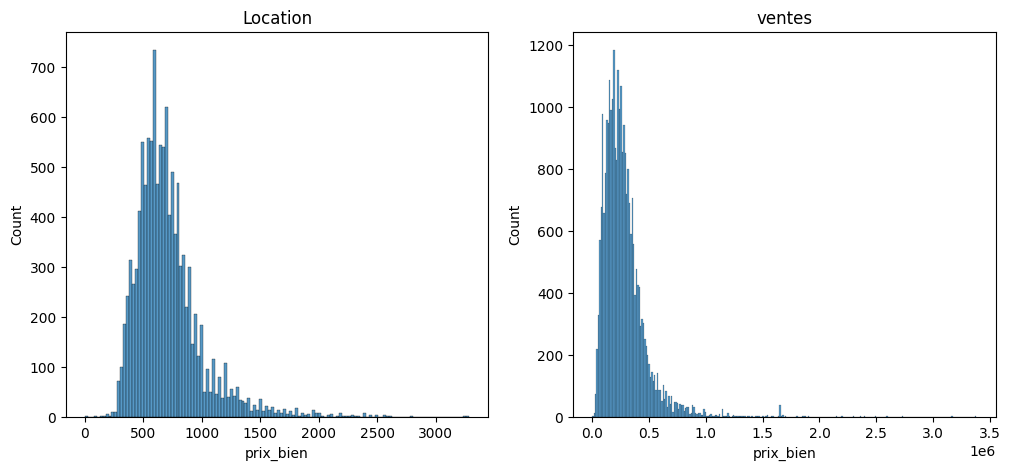

In [18]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(location["prix_bien"])
plt.title("Location")

plt.subplot(1,2,2)
sns.histplot(ventes["prix_bien"])  
plt.title("ventes")


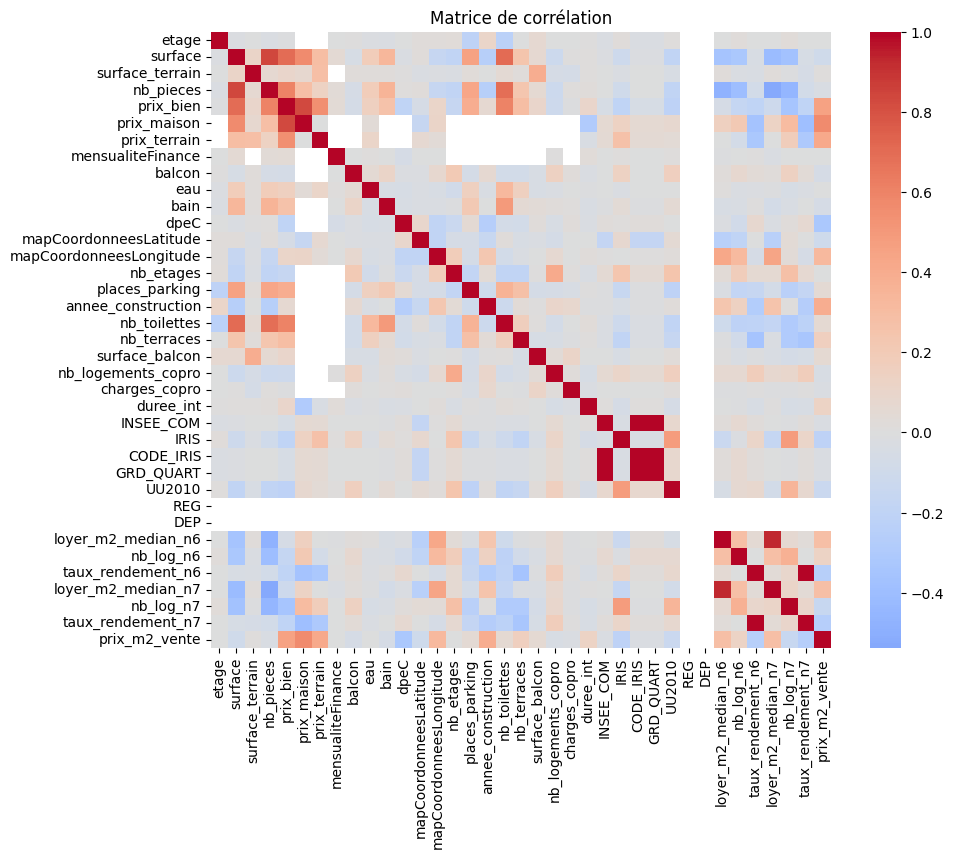

In [19]:
num_df = ventes.select_dtypes(include=["float64", "int64"])
corr = num_df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Matrice de corrélation")
plt.show()

In [20]:
corr_target = corr["prix_m2_vente"].sort_values(ascending=False)
print(corr_target)
corr_target = corr["prix_m2_vente"].sort_values(ascending=False)
print(corr_target)

prix_m2_vente              1.000000
prix_maison                0.564392
prix_bien                  0.456683
prix_terrain               0.411954
annee_construction         0.390980
mapCoordonneesLongitude    0.325657
loyer_m2_median_n7         0.283878
loyer_m2_median_n6         0.281337
nb_terraces                0.162980
nb_log_n6                  0.133448
duree_int                  0.123420
surface_balcon             0.057860
nb_toilettes               0.056928
places_parking             0.047857
surface_terrain            0.014704
etage                      0.001243
eau                       -0.000994
mensualiteFinance         -0.005893
nb_etages                 -0.006528
charges_copro             -0.022301
INSEE_COM                 -0.029624
GRD_QUART                 -0.029628
CODE_IRIS                 -0.029692
nb_pieces                 -0.036590
nb_logements_copro        -0.040628
bain                      -0.055865
balcon                    -0.056583
surface                   -0

In [21]:
cat_cols = ventes.select_dtypes(include=['object']).columns.tolist()
print(cat_cols)

['idannonce', 'type_annonceur', 'typedebien', 'typedetransaction', 'dpeL', 'annonce_exclusive', 'parking', 'cave', 'exposition', 'ges_class', 'videophone', 'porte_digicode', 'ascenseur', 'chauffage_energie', 'chauffage_systeme', 'chauffage_mode', 'categorie_annonceur', 'logement_neuf', 'typedebien_lite', 'date', 'TYP_IRIS_x', 'TYP_IRIS_y']


C:\Users\J1162513\AppData\Local\Temp\ipykernel_22224\877297043.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = ventes.select_dtypes(include=['object']).columns.tolist()


In [22]:
ventes_enc = ventes.copy()

In [23]:
le = LabelEncoder()
for col in cat_cols :
    ventes_enc[col]= le.fit_transform(ventes_enc[col].astype(str))
ventes_enc.head(5)

,idannonce,type_annonceur,typedebien,typedetransaction,etage,surface,surface_terrain,nb_pieces,prix_bien,prix_maison,...,UU2010,REG,DEP,loyer_m2_median_n6,nb_log_n6,taux_rendement_n6,loyer_m2_median_n7,nb_log_n7,taux_rendement_n7,prix_m2_vente
0,18002,0,0,1,0,64,NaN,3,128400,NaN,...,68113,44,68,NaN,NaN,NaN,NaN,NaN,NaN,2006.25
1,10611,0,3,1,0,85,4950.0,4,189000,NaN,...,68000,44,68,NaN,NaN,NaN,NaN,NaN,NaN,2223.53
2,22269,0,3,1,0,187,3182.0,9,282900,NaN,...,68000,44,68,NaN,NaN,NaN,NaN,NaN,NaN,1512.83
3,22274,0,0,1,0,76,NaN,4,79000,NaN,...,68000,44,68,7.93,3.0,0.092,7.93,3.0,0.092,1039.47
4,5677,0,3,1,0,90,3071.0,5,317000,NaN,...,68000,44,68,9.77,2.0,0.033,9.77,2.0,0.033,3522.22


<Axes: >

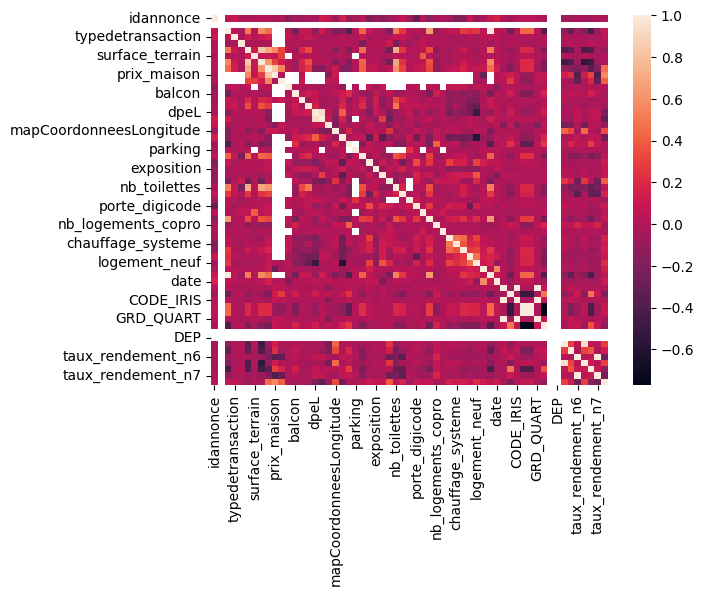

In [24]:
corr_matrix = ventes_enc.corr(numeric_only=True)
sns.heatmap(corr_matrix)

In [25]:
corr_target2 = corr_matrix["prix_m2_vente"].sort_values(ascending=False)

print(corr_target)

corr_target2 = corr_matrix["prix_m2_vente"].sort_values(ascending=False)

print(corr_target)

prix_m2_vente              1.000000
prix_maison                0.564392
prix_bien                  0.456683
prix_terrain               0.411954
annee_construction         0.390980
mapCoordonneesLongitude    0.325657
loyer_m2_median_n7         0.283878
loyer_m2_median_n6         0.281337
nb_terraces                0.162980
nb_log_n6                  0.133448
duree_int                  0.123420
surface_balcon             0.057860
nb_toilettes               0.056928
places_parking             0.047857
surface_terrain            0.014704
etage                      0.001243
eau                       -0.000994
mensualiteFinance         -0.005893
nb_etages                 -0.006528
charges_copro             -0.022301
INSEE_COM                 -0.029624
GRD_QUART                 -0.029628
CODE_IRIS                 -0.029692
nb_pieces                 -0.036590
nb_logements_copro        -0.040628
bain                      -0.055865
balcon                    -0.056583
surface                   -0

In [26]:
cible = 'prix_m2_vente'
corr_cible = corr_matrix[cible].sort_values(ascending = False)
corr_imp = corr_cible[(corr_target>0.2)| (corr_cible < -0.2)]
corr_imp = corr_imp.drop(cible)
print(corr_imp)

prix_maison                0.564392
prix_bien                  0.456683
prix_terrain               0.411954
annee_construction         0.390980
mapCoordonneesLongitude    0.325657
loyer_m2_median_n7         0.283878
loyer_m2_median_n6         0.281337
IRIS                      -0.214164
taux_rendement_n6         -0.251781
taux_rendement_n7         -0.259620
dpeC                      -0.322553
Name: prix_m2_vente, dtype: float64


In [27]:
# Test de voir les variables fortement corrélées entre elles a continuer
corr_abs

NameError: name 'corr_abs' is not defined